In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tqdm import tqdm

In [6]:
from pathlib import Path

DATASET_PATH = Path("../data/raw/EuroSAT")

print(DATASET_PATH.exists())
print(DATASET_PATH.resolve())

True
/home/speech/Desktop/Nishchala/Deforestation-detection/data/raw/EuroSAT


In [7]:
classes = sorted(
    [folder.name for folder in DATASET_PATH.iterdir()
     if folder.is_dir()]
)

print(classes)

print(len(classes))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
10


In [8]:
total_images = 0

for cls in classes:

    total_images += len(list((DATASET_PATH/cls).glob("*.jpg")))

print(total_images)

27000


In [9]:
rows = []

for cls in classes:

    count = len(list((DATASET_PATH/cls).glob("*.jpg")))

    rows.append({
        "Class": cls,
        "Images": count
    })

df = pd.DataFrame(rows)

df

,Class,Images
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


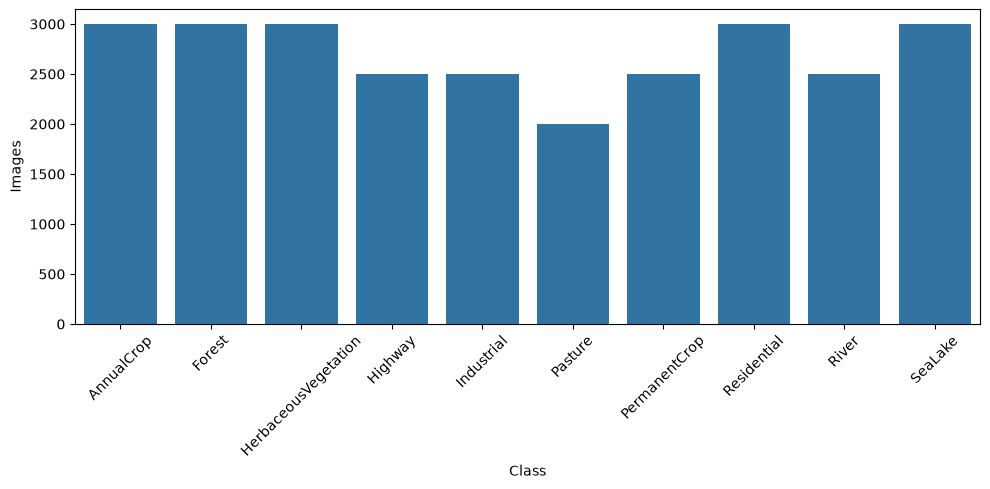

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Class",
    y="Images"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

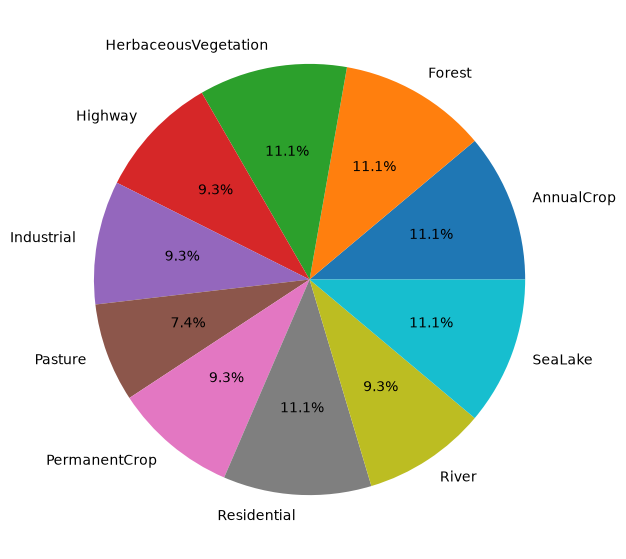

In [11]:
plt.figure(figsize=(7,7))

plt.pie(
    df["Images"],
    labels=df["Class"],
    autopct="%1.1f%%"
)

plt.show()

In [12]:
sizes = []

for cls in classes:

    for img_path in (DATASET_PATH/cls).glob("*.jpg"):

        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

print(np.unique(sizes,axis=0))

[[64 64]]


In [13]:
channels = []

for cls in classes:

    for img_path in (DATASET_PATH/cls).glob("*.jpg"):

        img = Image.open(img_path)

        channels.append(img.mode)

print(set(channels))

{'RGB'}


In [14]:
bad = []

for cls in classes:

    for img_path in (DATASET_PATH/cls).glob("*.jpg"):

        try:

            Image.open(img_path).verify()

        except:

            bad.append(img_path)

print(len(bad))

0


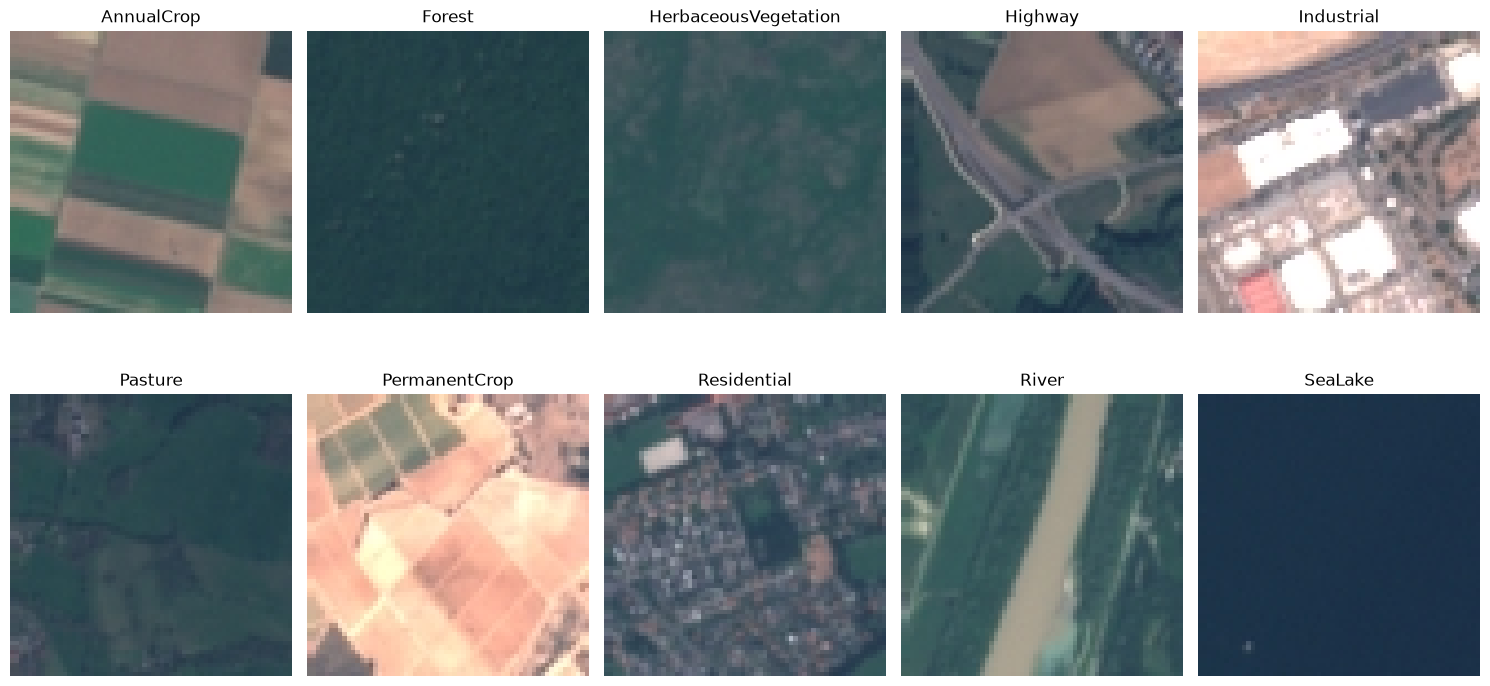

In [15]:
fig,axes = plt.subplots(2,5,figsize=(15,8))

for ax,cls in zip(axes.flatten(),classes):

    img = next((DATASET_PATH/cls).glob("*.jpg"))

    img = Image.open(img)

    ax.imshow(img)

    ax.set_title(cls)

    ax.axis("off")

plt.tight_layout()